##  Importing Libraries

In [ ]:
# Libraries for data manipulation and analysis
import pandas as pd
import numpy as np
# Libraries for visualization
# Setting up inline plotting for Jupyter notebooks
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
# Libraries for Model 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


## Loading the Data

In [39]:
# import csv file using pandas lib  
data = pd.read_csv("credit-card_customers.csv")

## Exploring the Data


In [40]:
# Check the shape (rows and columns) of the dataset
data.shape

(12126, 22)

- 12126 rows (Records)
- 22 columns (features or variables)

In [41]:
# Display the first 5 rows of the dataset
data.head()

,Customer_Number,Attrition_Flag,Age,Date_of_birth,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,3708092208,Existing Customer,45,6/9/1979,F,3,High School,Married,Less than $40K,Blue,...,3,3,3544.0,1661,1883.0,0.831,15149,111,0.734,0.469
1,3708093408,Attrited Customer,58,5/28/1966,M,0,Unknown,Single,$40K - $60K,Blue,...,1,3,3421.0,2517,904.0,0.992,992,21,0.400,0.736
2,3708094683,Attrited Customer,46,6/29/1978,M,3,Doctorate,Divorced,$80K - $120K,Blue,...,3,3,8258.0,1771,6487.0,0.000,1447,23,0.000,0.214
3,3708095583,Existing Customer,34,6/23/1990,F,2,Uneducated,Single,Less than $40K,Blue,...,2,2,1438.3,0,1438.3,0.827,3940,82,0.952,0.000
4,3708097083,Existing Customer,49,3/12/1975,F,2,Uneducated,Married,Unknown,Blue,...,5,2,3128.0,749,2379.0,0.598,4369,59,0.735,0.239


In [42]:
# Display the last 5 rows
data.tail()

,Customer_Number,Attrition_Flag,Age,Date_of_birth,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
12121,3828298458,Existing Customer,50,3/29/1974,M,0,Uneducated,Married,$60K - $80K,Blue,...,1,3,3640.0,659,2981.0,0.938,3756,70,0.842,0.181
12122,3828301983,Attrited Customer,38,5/15/1986,M,3,College,Single,$60K - $80K,Blue,...,3,4,12050.0,1821,10229.0,0.630,2381,40,0.481,0.151
12123,3828305058,Attrited Customer,49,2/17/1975,F,3,High School,Married,Less than $40K,Blue,...,2,3,2951.0,2437,514.0,0.765,2519,36,0.565,0.826
12124,3828309033,Existing Customer,54,3/4/1970,M,4,Graduate,Married,$120K +,Blue,...,2,0,2872.0,2035,837.0,0.613,1770,47,0.741,0.709
12125,3828353208,Existing Customer,43,7/26/1981,F,4,High School,Unknown,Less than $40K,Blue,...,3,3,2786.0,1793,993.0,0.803,3646,68,0.659,0.644


### Data Overview

In [43]:
# Get data info (data types and missing values)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12126 entries, 0 to 12125
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_Number           12126 non-null  int64  
 1   Attrition_Flag            12026 non-null  object 
 2   Age                       12126 non-null  int64  
 3   Date_of_birth             12126 non-null  object 
 4   Gender                    11926 non-null  object 
 5   Dependent_count           12126 non-null  int64  
 6   Education_Level           11926 non-null  object 
 7   Marital_Status            12126 non-null  object 
 8   Income_Category           12126 non-null  object 
 9   Card_Category             11924 non-null  object 
 10  Months_on_book            12126 non-null  int64  
 11  Total_Relationship_Count  12126 non-null  int64  
 12  Months_Inactive_12_mon    12126 non-null  int64  
 13  Contacts_Count_12_mon     12126 non-null  int64  
 14  Credit

- we found less than 12126 in
1. Attrition_Flag,
2. Gender,
3. Education_level,
4. Card_category 
- we found data type of Date is object we need to convert this data type to date time

In [45]:
# View summary statistics of the numerical columns
data.describe()

,Customer_Number,Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.212600e+04,12126.000000,12126.000000,12126.000000,12126.000000,12126.000000,12126.000000,12126.000000,12126.000000,12126.000000,12126.000000,12126.000000,12126.000000,12126.000000,12126.000000
mean,3.742948e+09,46.729672,2.344302,35.842570,3.810407,2.347188,2.452251,8268.303224,1178.020122,7231.967829,0.758461,4385.389494,64.732806,0.709325,0.288685
std,3.786269e+07,12.508319,1.289627,7.959591,1.552042,1.008596,1.104960,8964.526988,820.392423,8986.507104,0.220927,3382.962202,23.558367,0.237589,0.286073
min,3.708092e+09,5.000000,0.000000,13.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,3.713645e+09,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2454.500000,465.000000,1197.000000,0.628000,2144.250000,45.000000,0.579000,0.026000
50%,3.719272e+09,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4182.000000,1293.000000,3224.000000,0.735000,3891.000000,67.000000,0.700000,0.187000
75%,3.779080e+09,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,10572.000000,1800.000000,9575.000000,0.859000,4739.000000,81.000000,0.818000,0.539000
max,3.828353e+09,120.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


## Data Cleaning

In [ ]:
# Convert 'Date_of_birth' to datetime format
data['Date_of_birth'] = pd.to_datetime(data['Date_of_birth'])

In [ ]:
# Check data types to confirm 'Date_of_birth' was converted
data.dtypes

In [1]:
# Check for duplicates in the data
data.duplicated().sum()

NameError: name 'data' is not defined

In [ ]:
# Remove duplicates (if any)
data = data.drop_duplicates()

In [ ]:
# Verify if duplicates are removed
data.duplicated().sum()

In [ ]:
# Check for missing values in the dataset
missing_Value=data.isnull().sum()
missing_Value[missing_Value>0]


In [ ]:
# Fill missing values with the mode (most frequent value) for categorical columns
data.fillna(data.mode().iloc[0], inplace=True)

In [36]:
data = data[data['Attrition_Flag'] != 'Unknown']


### Dropping Irrelevant Columns


In [ ]:
# Drop columns that are not relevant for analysis
data_clean = data.drop(columns=['Date_of_birth', 'Customer_Number'])

In [ ]:
# Check if columns were dropped successfully
data_clean.info()

### Converting Categorical Data to Appropriate Type


In [ ]:
# Convert categorical columns to 'category' type
category_columns = data_clean.select_dtypes(include="object").columns.tolist()
data_clean[category_columns] = data_clean[category_columns].astype("category")

In [ ]:
# Verify the data type conversion
data_clean.dtypes

## Data Export for Power BI


In [ ]:
# Export the cleaned data to Excel for further analysis in Power BI
# data_clean.to_excel("Data_clean.xlsx")

## Visualizing Numerical Columns (Boxplots)


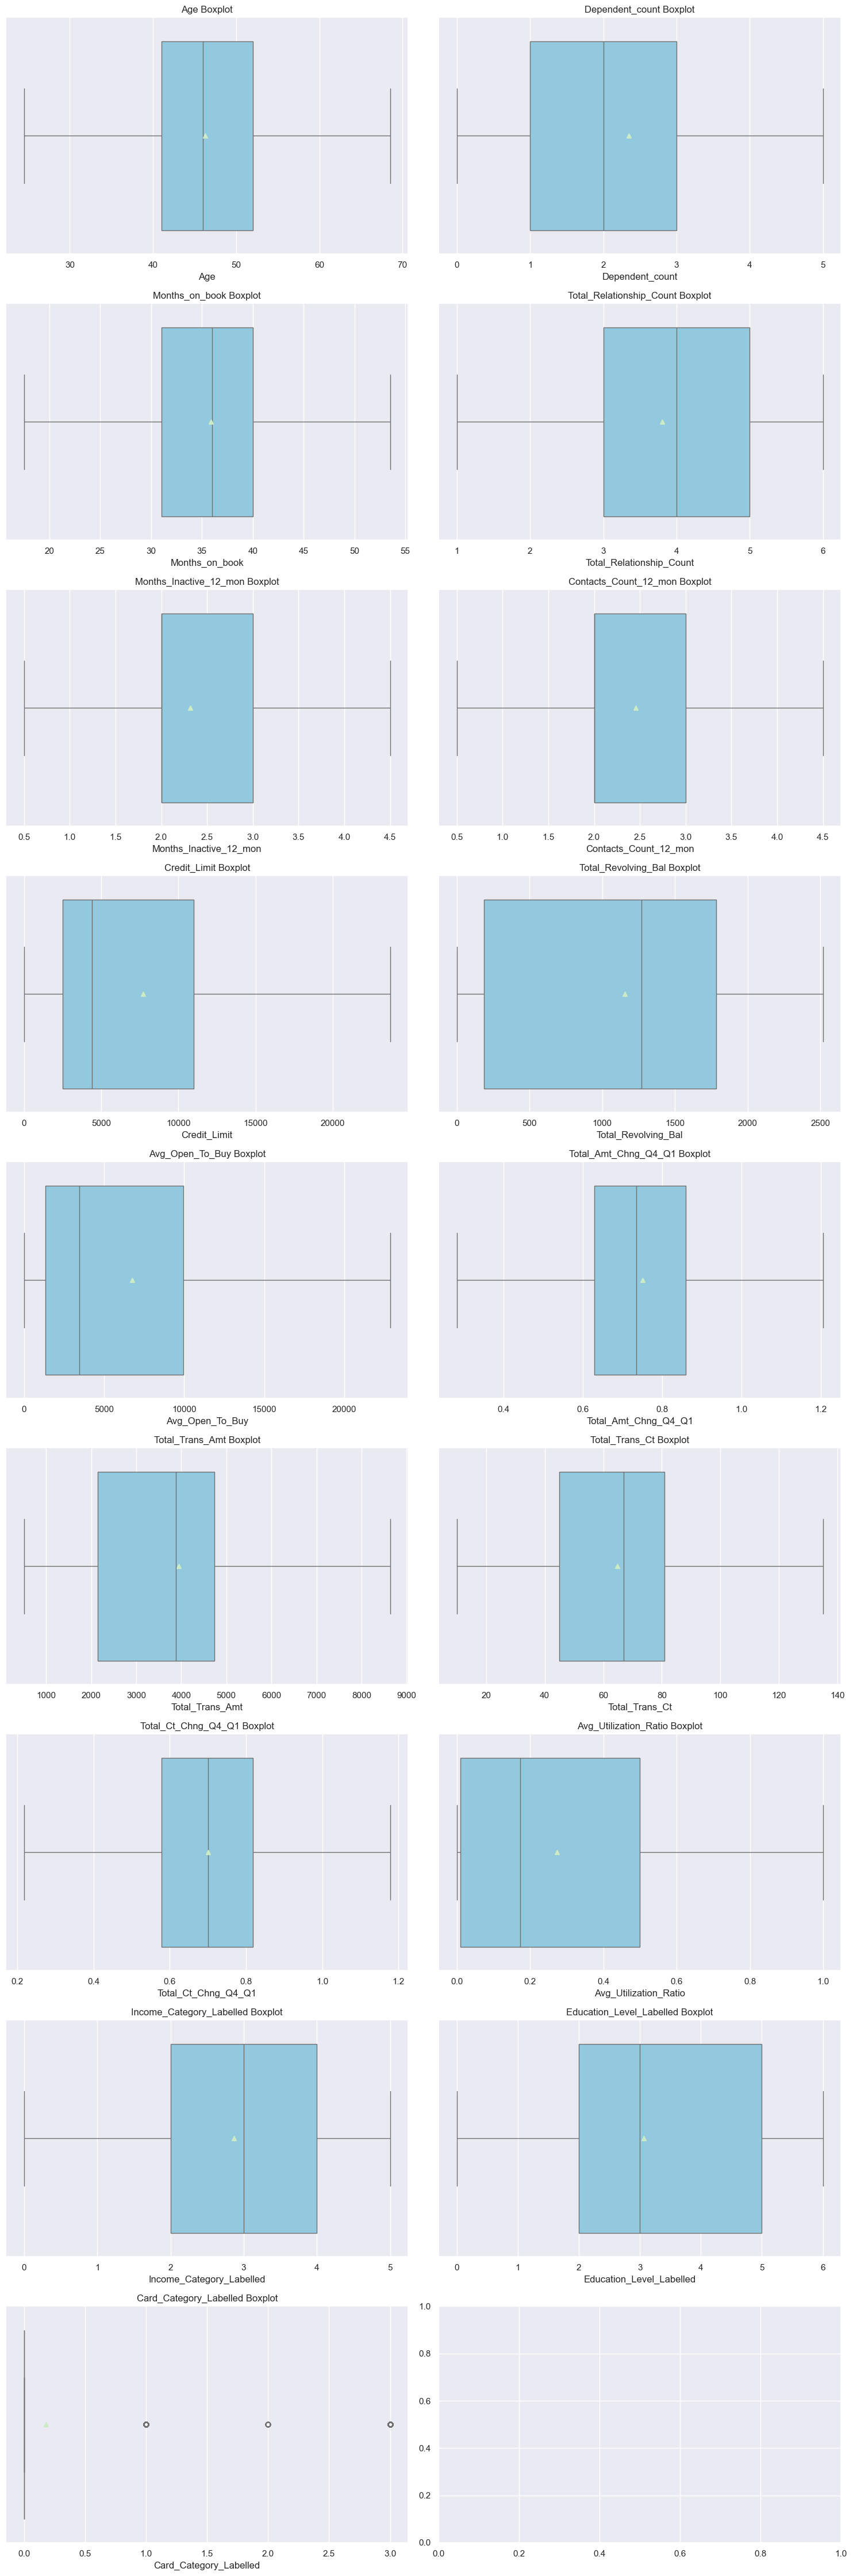

In [37]:


# Select numerical columns 
numeric_cols = data_clean.select_dtypes(include="number").columns.tolist()
# Set the number of rows and columns based on the number of plots needed
n_cols = 2  # Number of columns per row
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  # Calculate the number of rows needed

# Set up the figure for multiple subplots
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 5))
plt.subplots_adjust(hspace=0.6)
sns.set_palette("Pastel1")

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot boxplots for each numerical column
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=data_clean[col], color="skyblue", ax=axes[i], showmeans=True)
    axes[i].set_title(f"{col} Boxplot")


# Tight layout for better spacing
plt.tight_layout()
plt.show()


## Bi Variety


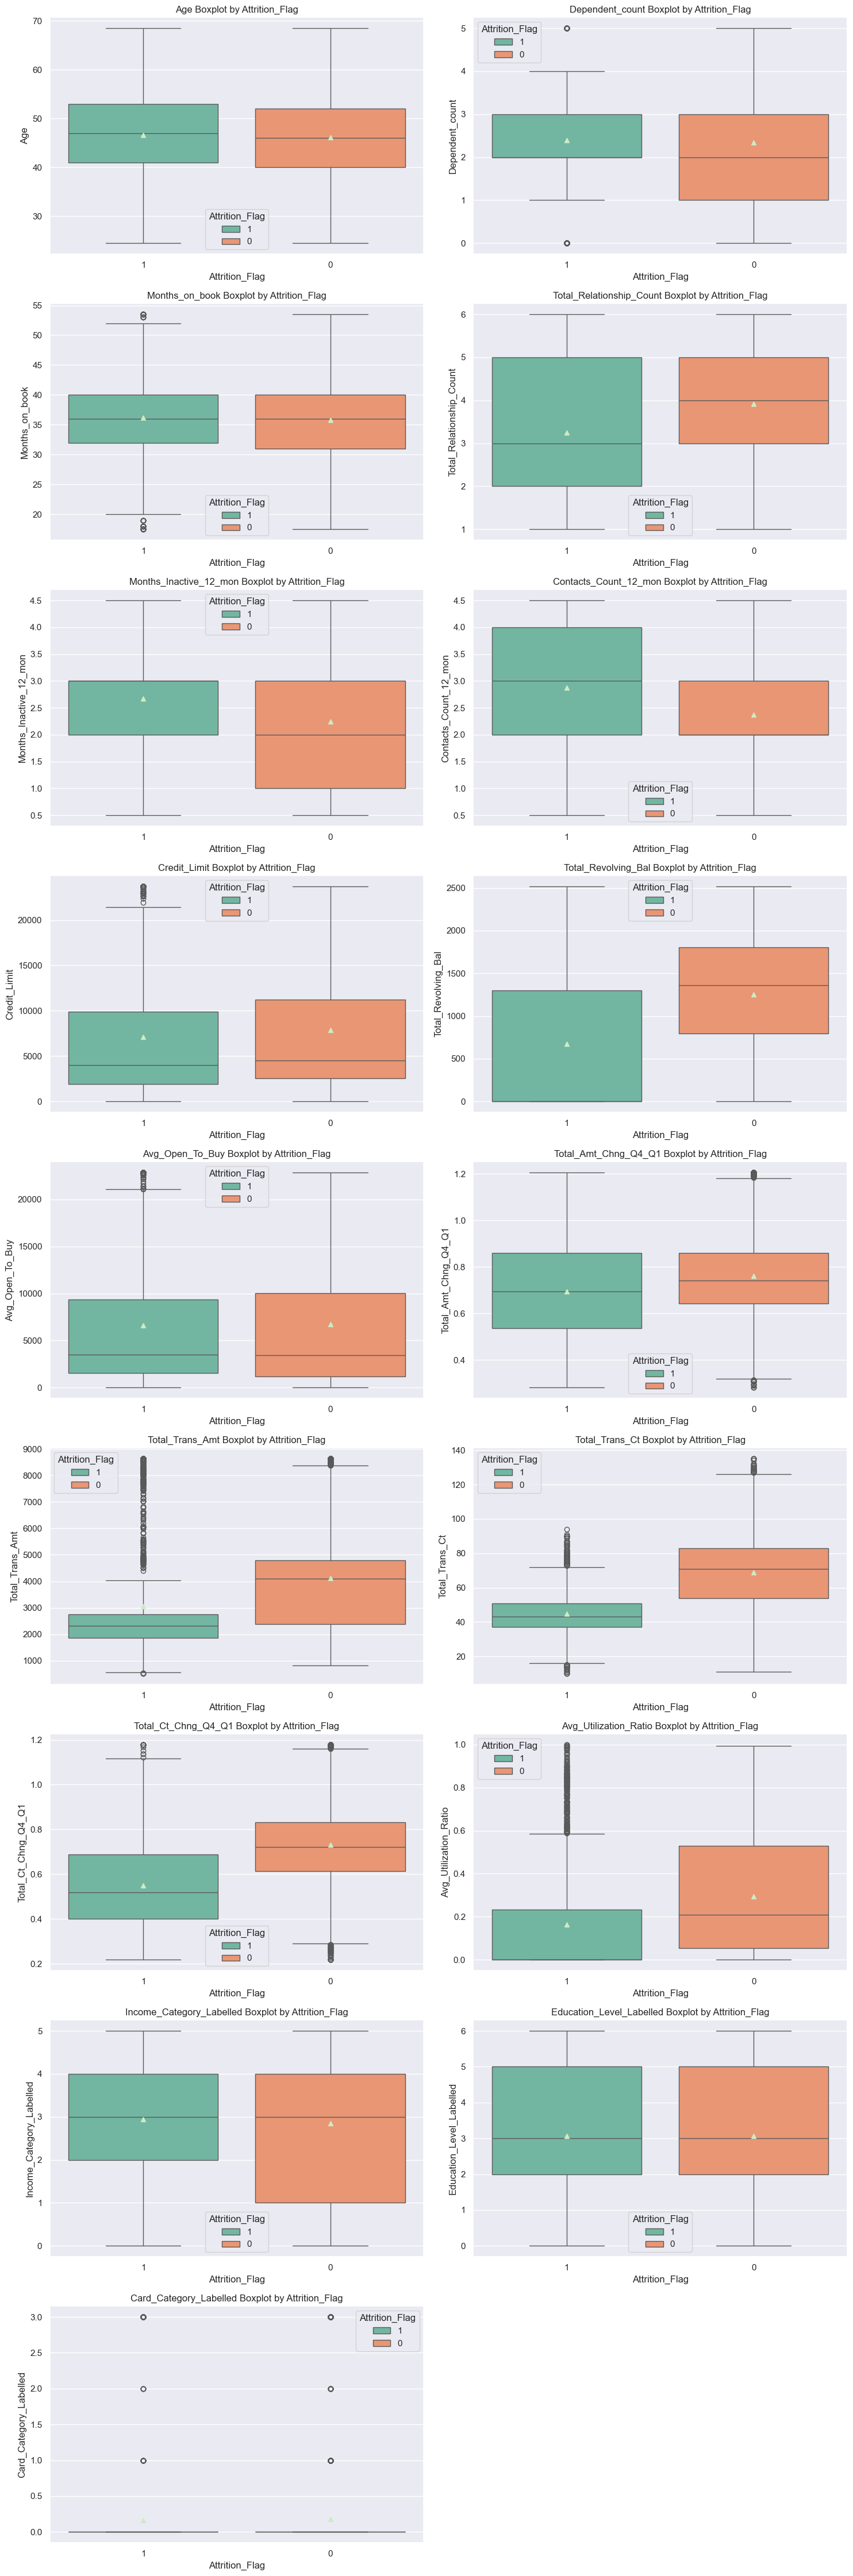

In [38]:
# Select numerical columns 
numeric_cols = data_clean.select_dtypes(include="number").columns.tolist()

# Set the number of rows and columns based on the number of plots needed
n_cols = 2  # Number of columns per row
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  # Calculate the number of rows needed

# Set up the figure for multiple subplots
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 5))
plt.subplots_adjust(hspace=0.6)

# Plot boxplots for each numerical column, grouped by Attrition_Flag
for i, col in enumerate(numeric_cols):
    sns.boxplot(x='Attrition_Flag', y=col, data=data_clean, ax=axes[i // n_cols, i % n_cols], showmeans=True, palette="Set2", hue='Attrition_Flag')
    axes[i // n_cols, i % n_cols].set_title(f"{col} Boxplot by Attrition_Flag")

# Remove any empty subplots
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j // n_cols, j % n_cols])

# Tight layout for better spacing
plt.tight_layout()
plt.show()


### Identifying and Handling Outliers


In [ ]:
# Function to find columns with outliers using the IQR method
def find_outliers_columns(df):
    outliers_columns = []
    for column in df.select_dtypes(include=[np.number]):
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        IQR = q3 - q1
        lower_bound = q1 - 1.5 * IQR
        upper_bound = q3 + 1.5 * IQR
        if ((df[column] < lower_bound) | (df[column] > upper_bound)).any():
            outliers_columns.append(column)
    return outliers_columns


# Use the function to find columns with outliers
outliers_columns_list = find_outliers_columns(data_clean)
print("Columns with outliers:", outliers_columns_list)

In [ ]:
# Function to Cap outliers using the IQR method
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    return df





# Columns to check for outliers
columns_to_check = ['Age', 'Months_on_book', 'Months_Inactive_12_mon',
                    'Contacts_Count_12_mon', 'Credit_Limit', 'Avg_Open_To_Buy',
                    'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct',
                    'Total_Ct_Chng_Q4_Q1']

# cap outliers for each selected column
for col in columns_to_check:
    data_clean = cap_outliers(data_clean, col)

# Display the data summary after cap outliers
data_clean.describe()


## Correlation Analysis


In [ ]:
# Map the target variable (Attrition Flag) to numeric values
codes = {'Existing Customer': 0, 'Attrited Customer': 1}
data_clean_2 = data_clean.copy()
data_clean_2['Attrition_flag'] = data_clean_2['Attrition_Flag'].map(codes).astype(int)

# Select only numerical columns
data_clean_2 = data_clean_2.select_dtypes(include=[np.number])

# Plot a correlation heatmap
sns.set(rc={"figure.figsize": (15, 15)})
sns.heatmap(data_clean_2.corr(), annot=True, linewidths=0.5, center=0, cbar=False, cmap="YlGnBu", fmt="0.2f")
plt.show()

## Data Preprocessing for Model Building


In [ ]:

# Label encoding for categorical variables
le = LabelEncoder()
data_clean['Income_Category_Labelled'] = le.fit_transform(data_clean['Income_Category'])
data_clean['Education_Level_Labelled'] = le.fit_transform(data_clean['Education_Level'])
data_clean['Card_Category_Labelled'] = le.fit_transform(data_clean['Card_Category'])

# Drop original categorical columns
data_clean = data_clean.drop(['Education_Level', 'Income_Category', 'Card_Category'], axis=1)

# Map 'Attrition_Flag' to binary values (1 for existing, 0 for attrited)
data_clean['Attrition_Flag'] = data_clean['Attrition_Flag'].map({'Existing Customer': 0, 'Attrited Customer': 1})

# Create dummy variables for Gender and Marital_Status
new_df = pd.get_dummies(data_clean, columns=['Gender', 'Marital_Status'], drop_first=True, dtype='int')

# Split the dataset into features (X) and target (y)
X = new_df.drop('Attrition_Flag', axis=1)
y = new_df['Attrition_Flag']

# Split the data into training and test sets (81% train, 19% test)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=20,stratify=y)

## Model Building


In [ ]:
# Logistic Regression Model
lr_model = LogisticRegression(max_iter=2000, solver='newton-cg', class_weight='balanced')
lr_model.fit(x_train, y_train)
lr_predictions = lr_model.predict(x_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)

# Random Forest Classifier
rf_model = RandomForestClassifier()
rf_model.fit(x_train, y_train)
rf_predictions = rf_model.predict(x_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

# Print accuracy for each model
print("Logistic Regression Accuracy:", lr_accuracy * 100, "%")
print("Random Forest Accuracy:", rf_accuracy * 100, "%")

# Generate classification reports for both models
print("\nLogistic Regression Report:")
print(classification_report(y_test, lr_predictions))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_predictions))

## Customer Churn Prediction Probabilities

In [ ]:
# Predict churn probabilities
lr_probabilities = lr_model.predict_proba(x_test)[:, 1]
rf_probabilities = rf_model.predict_proba(x_test)[:, 1]

# Create a DataFrame of customers with their churn probabilities
customers_at_risk = pd.DataFrame({
    'Index': x_test.index,
    'LR_Churn_Probability': lr_probabilities,
    'RF_Churn_Probability': rf_probabilities
})

# Sort customers by highest churn risk
customers_at_risk.sort_values(by='RF_Churn_Probability', ascending=False).head(20)


In [ ]:
from sklearn.metrics import roc_curve

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probabilities)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probabilities)

plt.plot(lr_fpr, lr_tpr, label='Logistic Regression AUC')
plt.plot(rf_fpr, rf_tpr, label='Random Forest AUC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()